<div style="color: white; background-color: purple; font-size: 28px; font-weight: bold; text-align: center; padding: 20px;">
UNSUPERVISED LEARNING: <br> -Market Segmentation in Insurance-
</div>

______________________________________________________________________________________________________________________
by Vinh Dac

<div style="font-size:15px;border: 1px solid black; padding: 5px; border-radius: 3px; width: fit-content;">

# <a id='0'>Table of contents</a>

- <a href='#1'>Introduction</a>
- <a href='#2'>Key findings</a>
     - <a href='#21'>Key clusters</a>
     - <a href='#22'>Model evaluation</a>
     - <a href='#23'>Model results</a>  
- <a href='#3'>Import required libraries</a>  
- <a href='#4'>Read the data</a>  
- <a href='#5'>Check the data</a>  
- <a href='#6'> Exploratory Data Analysis</a>
- <a href='#7'>Predictive models</a>  
    - <a href='#71'>Dimensionality reduction</a> 
    - <a href='#72'>KMeans</a>     
    - <a href='#73'>DBSCAN</a> 
    - <a href='#74'>Meanshift</a> 
    - <a href='#75'>Ward</a> 
- <a href='#8'>Conclusions</a>
- <a href='#9'>References</a>



# <a id="1">Introduction</a>
**WHAT IS MARKET SEGMENTATION?**

In marketing, market segmentation is the process of dividing a broad consumer or business market, normally consisting of existing and potential customers, into subgroups of consumers based on some type of shared characteristics.

**Objective :**

This case requires developing a customer segmentation to give recommendations like saving plans, loans, wealth management, etc. on target customer groups.

**Dataset:**

The sample Dataset summarizes the usage behavior of about 9000 active credit cardholders during the last 6 months. The file is at a customer level with 18 behavioral variables.
* Variables of Dataset
* Balance
* Balance Frequency
* Purchases
* One-off Purchases
* Installment Purchases
* Cash Advance
* Purchases Frequency
* One-off Purchases Frequency
* Purchases Installments Frequency
* Cash Advance Frequency
* Cash Advance TRX
* Purchases TRX
* Credit Limit
* Payments
* Minimum Payments
* PRC Full payment
* Tenure
* Cluster

The sample Dataset summarizes the usage behavior of about 9000 active credit cardholders during the last 6 months. The file is at a customer level with 18 behavioral variables.

# <a id="2">Key findings</a>

### <a id="21">Key Clusters</a>

Cluster 1: **"Low-Volume Pragmatists"**
* Characterized by low financial activity and low credit utilization.
* Tend to maintain low balances and engage in minimal transactions, focusing on stability rather than volume.

Cluster 2: **"High-Volume Power Users"**
* Exhibit high transaction volumes and significant variability in credit limits.
* These are likely the heavy users of financial services, actively engaging with their accounts.

Cluster 3: **"Diverse Low-Volume Users"**
* Similar to Cluster 1 but with greater variability in their financial behavior.
* May indicate a mix of sporadic or inconsistent usage patterns.

Cluster 4: **"Frequent Spenders"**
* Resemble Cluster 2 but with a distinct focus on frequent purchases, particularly installment-based transactions.
* High variability in payment behaviors suggests a mix of disciplined and opportunistic spending habits.


![Market Segment](barchart123.pdf)

### <a id="22">Model evaluations</a>

    
**Best Model: K-Means**

* Davies-Bouldin Index: Lower values indicate better clustering, and K-Means (0.80) is the best here.
* Silhouette Score: DBSCAN (0.78) is the highest, indicating better cohesion and separation within clusters, but K-Means still performs reasonably well at 0.40.
* Calinski-Harabasz Index: Higher values are better for cluster separation, and K-Means (5818.79) has the highest value, suggesting it's the best at separating clusters.





### Model results:


| ratio | DBSCAN| Hierarchical  | K-Means |MeanShift|
|---|---|---|---|---|
| Davies-Bouldin Index| 1.11 | 0.83 | 0.80| 0.54| 
| Silhouette Score| 0.78 | 0.37 | 0.40| 0.55| 
| Calinski-Harabasz Index| 466.9 | 4902.8 | 5818.79| 370.75| 
 





![Market Segment](model.pdf)

# <a id="3">Import Required Libraries</a>

In [1]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import MeanShift

In [3]:
def plot_explained_variance(pca):
    # This function graphs the accumulated explained variance ratio for a fitted PCA object.
    acc = [*accumulate(pca.explained_variance_ratio_)]
    fig, ax = plt.subplots(1, figsize=(50, 20))
    ax.stackplot(range(pca.n_components_), acc)
    ax.scatter(range(pca.n_components_), acc, color='black')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, pca.n_components_-1)
    ax.tick_params(axis='both', labelsize=36)
    ax.set_xlabel('N Components', fontsize=48)
    ax.set_ylabel('Accumulated explained variance', fontsize=48)
    plt.tight_layout()
    plt.show()

# <a id="4">Read the data</a>

In [4]:
data=pd.read_csv('/kaggle/input/market-segmentation-in-insurance-unsupervised/Customer Data.csv')
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

According to the output above, we have 8950 entries or rows, as well as 17 features. The "Non-Null Count" column shows the number of non-null entries. If the count is 8950 then **there is missing values for  CREDIT_LIMIT, MINIMUM_PAYMENTS  feature.**

The describe() function will provide the statistical information about all numeric values.

# <a id="5">Check the data</a>

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [7]:
data.dtypes.value_counts()

float64    14
int64       3
object      1
Name: count, dtype: int64

The ID is unique, so including it has no meaning; therefore, it should be dropped.

In [8]:
data=data.drop('CUST_ID', axis=1)

Filling the missing value with median value 

In [9]:
data["MINIMUM_PAYMENTS"] = data["MINIMUM_PAYMENTS"].fillna(data["MINIMUM_PAYMENTS"].median())
data["CREDIT_LIMIT"] = data["CREDIT_LIMIT"].fillna(data["CREDIT_LIMIT"].median())

In [10]:
data.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

# <a id="6"> Exploratory Data Analysis</a>


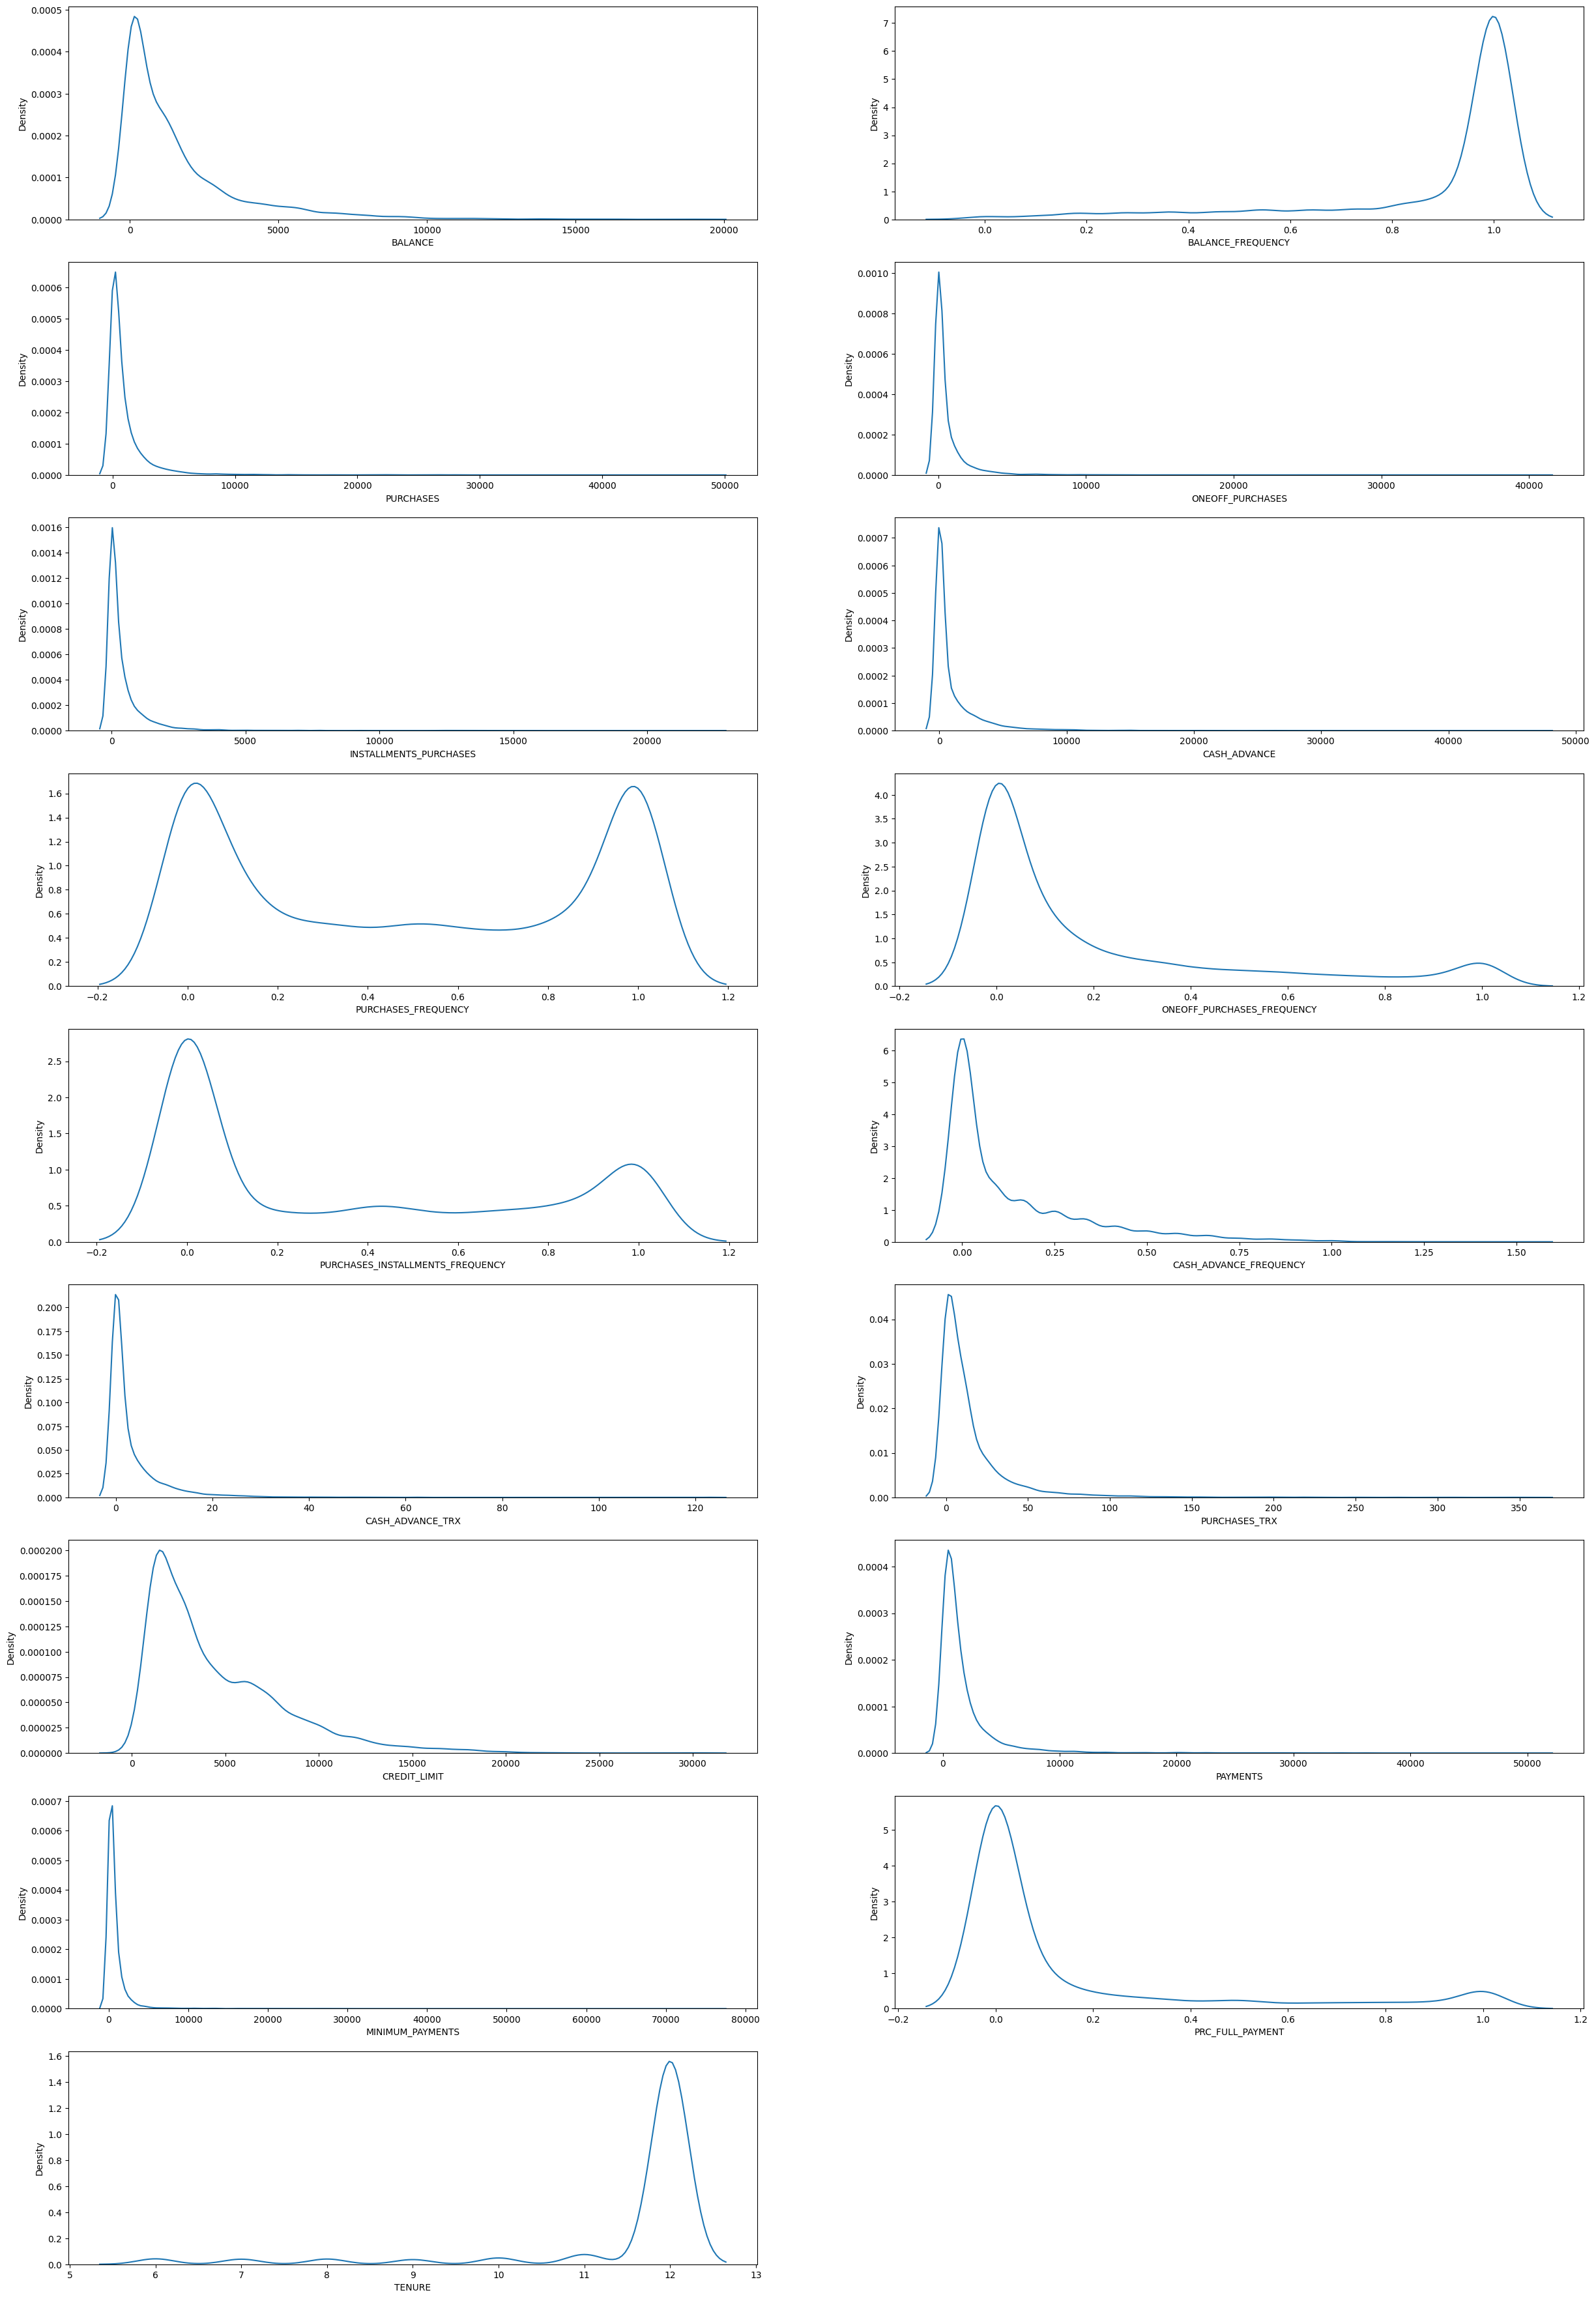

In [11]:
plt.figure(figsize=(30, 45))
for i, column in enumerate(data.columns):
    if data[column].dtype != 'object':
        ax = plt.subplot(9, 2, i + 1)
        sns.kdeplot(data[column], ax=ax)
        plt.xlabel(column)

plt.show()


<div style="font-size:15px;border: 1px solid black; padding: 5px; border-radius: 3px; width: fit-content;">
    
**Note**: 
The data is heavily skewed in each feature.


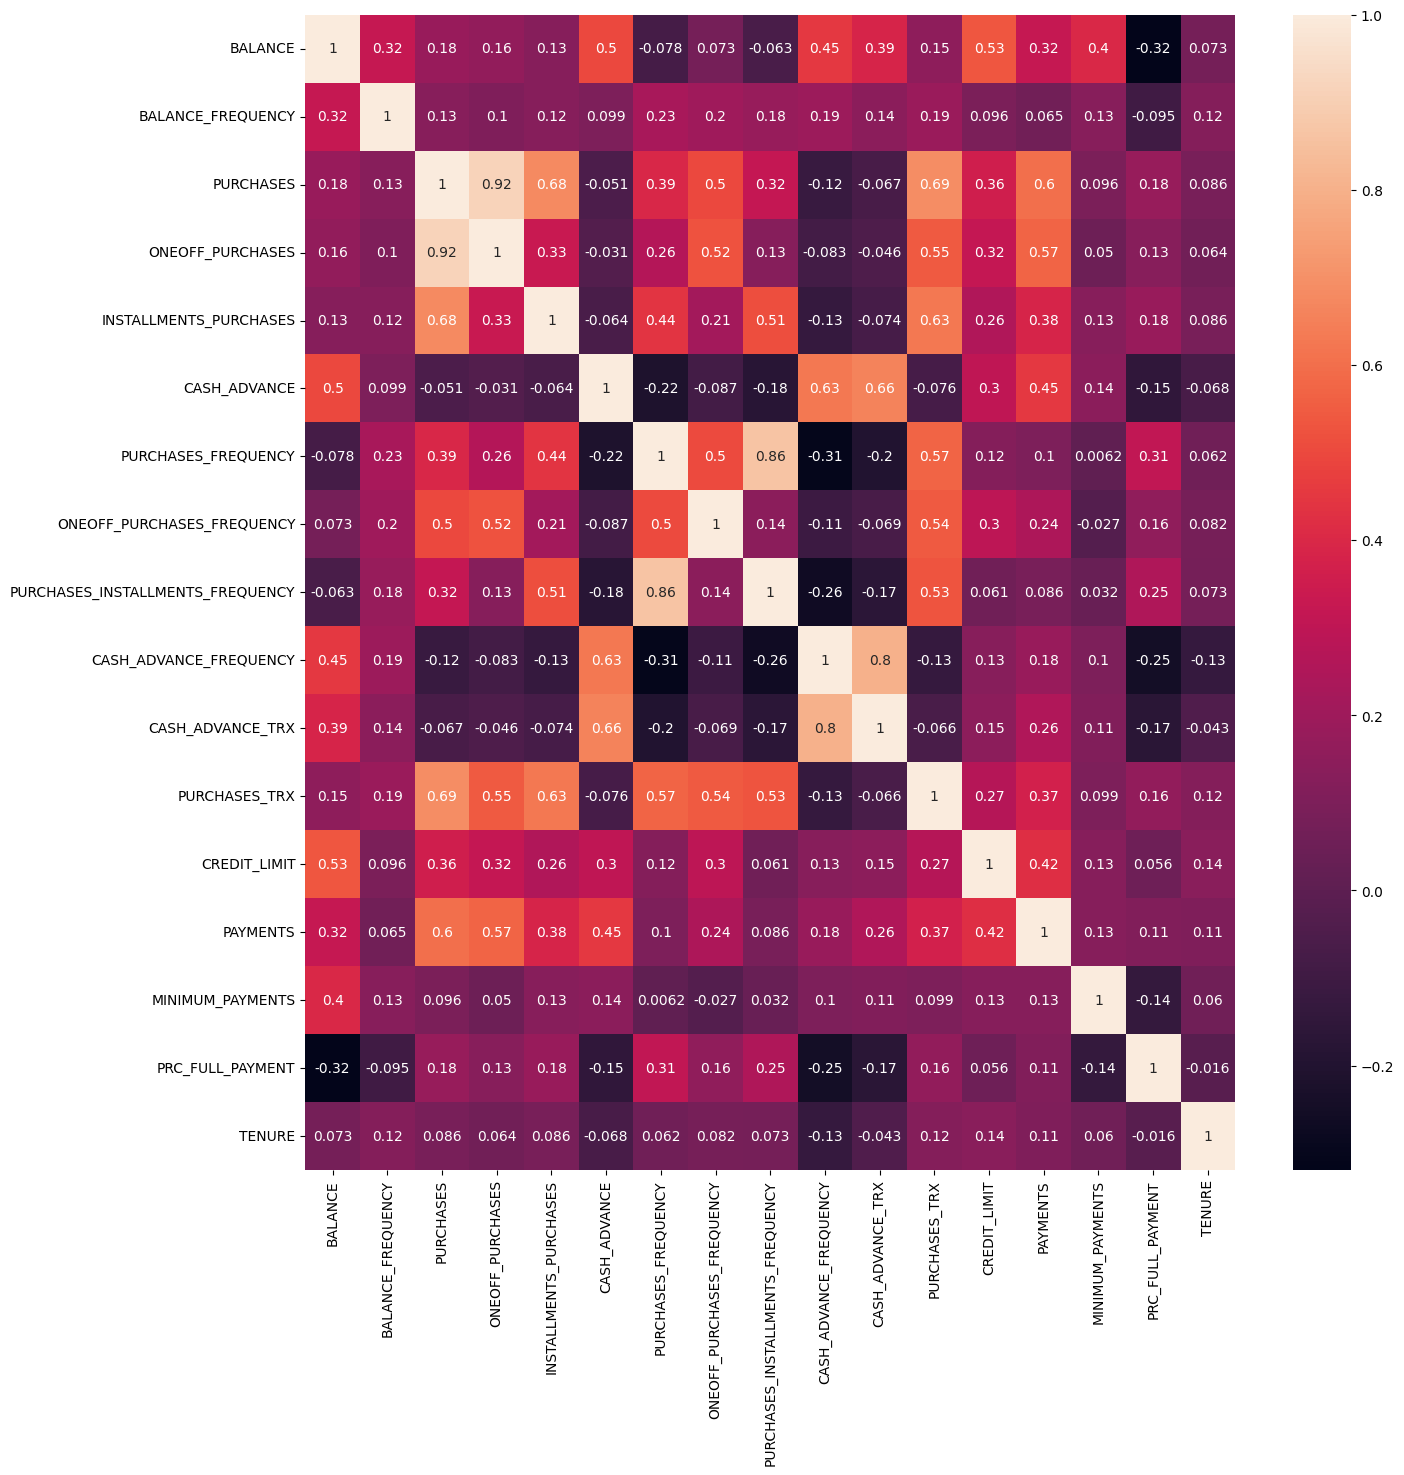

In [12]:
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(), annot=True)
plt.show()

<div style="font-size:15px;border: 1px solid black; padding: 5px; border-radius: 3px; width: fit-content;">
    
**Note**: 
Low correlation between features.


# <a id="7">Predictive models</a>

### <a id="71">Dimensionality reduction</a>

### How does PCA work? 

1.  Looks at an $n$ -dimensional dataset and breaks it down into "general trends" or **components**

```
- When we say "$n$-dimensional", we mean the data has $n$ features.
```

2.  The components are then **sorted by how much of the explained variance they account for** (*eigenvalues* provide this information)

```
- This means if a component is highly-uncorrelated with all others, it's a "strong" component and provides useful information that is very hard to infer from all other components.
```

3.  Then, given some parameter (usually chosen by the data engineer), the new dimension of the data is decided. Let this be $k$.

```
- Note $k$ is always $k \leq n$ because we're only trying to reduce the dimension of our data.
```

4.  Finally, the original $n$ dimensional dataset is projected onto the $k$-dimensional plane chosen by our **top-$k$ components that take care of the most explained variance**.

```
- These top- $k$ components are now used 
```

Because principle components span an (at most) $k$-dimensional surface, we have successfully reduced our data to at least $k \leq n$ dimensions!


### Scaling data

In [13]:
scalar=StandardScaler()

In [14]:
scaled_df = scalar.fit_transform(data)

In [15]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(data=principal_components ,columns=["PCA1","PCA2"])
pca_df

,PCA1,PCA2
0,-1.683649,-1.072244
1,-1.134076,2.509154
2,0.969381,-0.383588
3,-0.888223,0.004643
4,-1.600020,-0.683797
...,...,...
8945,-0.362573,-2.013439
8946,-0.580816,-1.675671
8947,-0.928987,-1.808052
8948,-2.337842,-0.653609


### <a id="72">KMeans</a>


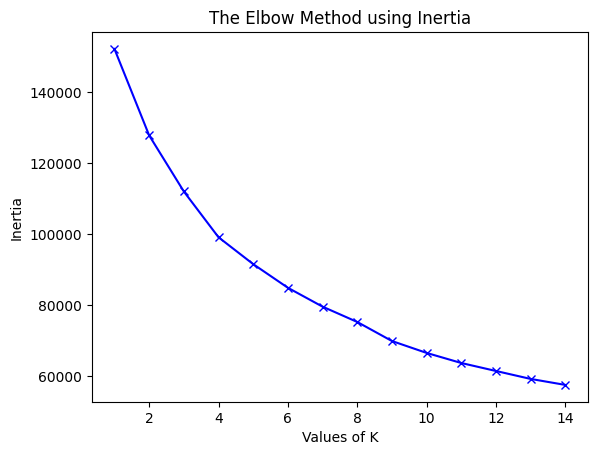

In [16]:
inertia = []
range_val = range(1,15)
for i in range_val:
    kmean = KMeans(n_clusters=i)
    kmean.fit_predict(pd.DataFrame(scaled_df))
    inertia.append(kmean.inertia_)
plt.plot(range_val,inertia,'bx-')
plt.xlabel('Values of K') 
plt.ylabel('Inertia') 
plt.title('The Elbow Method using Inertia') 
plt.show()

Model using Kmeans

       PCA1      PCA2  Cluster
0 -1.683649 -1.072244        2
1 -1.134076  2.509154        1
2  0.969381 -0.383588        0
3 -0.888223  0.004643        2
4 -1.600020 -0.683797        2


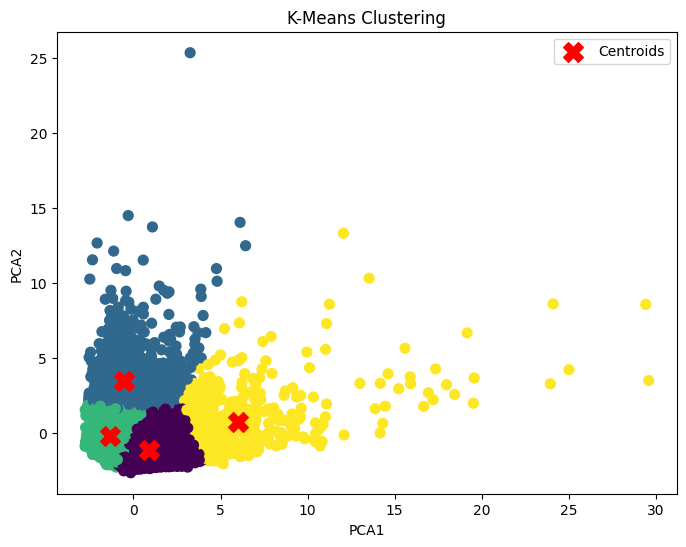

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(pca_df[["PCA1", "PCA2"]])

pca_df['Cluster'] = kmeans_labels

print(pca_df.head())

plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PCA1"], pca_df["PCA2"], c=pca_df["Cluster"], cmap="viridis", s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.savefig('model.pdf')
plt.show()

### <a id="73">DBSCAN</a>

In [18]:
from sklearn.metrics import silhouette_score

In [19]:
eps_values = np.arange(0.1, 1.0, 0.1)
min_samples_values = range(2, 10)

best_score = -1
best_params = {}

# Grid Search
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(pca_df[["PCA1", "PCA2"]])
        
        # Bỏ qua nếu tất cả các điểm nằm trong nhiễu
        if len(set(labels)) <= 1:
            continue
        
        # Tính silhouette score
        score = silhouette_score(pca_df[["PCA1", "PCA2"]], labels)
        print(f"eps: {eps}, min_samples: {min_samples}, silhouette score: {score}")
        
        if score > best_score:
            best_score = score
            best_params = {"eps": eps, "min_samples": min_samples}

# Kết quả tốt nhất
print(f"Best Parameters: {best_params}")
print(f"Best Silhouette Score: {best_score}")

eps: 0.1, min_samples: 2, silhouette score: -0.38396422798652685
eps: 0.1, min_samples: 3, silhouette score: -0.3252057771536119
eps: 0.1, min_samples: 4, silhouette score: -0.29104378542953885
eps: 0.1, min_samples: 5, silhouette score: -0.4104084599746315
eps: 0.1, min_samples: 6, silhouette score: -0.43403097057991585
eps: 0.1, min_samples: 7, silhouette score: -0.4849254630111672
eps: 0.1, min_samples: 8, silhouette score: -0.5313640386652689
eps: 0.1, min_samples: 9, silhouette score: -0.5528207922114912
eps: 0.2, min_samples: 2, silhouette score: 0.12551389637387605
eps: 0.2, min_samples: 3, silhouette score: 0.14808032377907637
eps: 0.2, min_samples: 4, silhouette score: 0.14378855261962348
eps: 0.2, min_samples: 5, silhouette score: 0.1341335599417445
eps: 0.2, min_samples: 6, silhouette score: 0.09502594942126126
eps: 0.2, min_samples: 7, silhouette score: 0.06449700071540695
eps: 0.2, min_samples: 8, silhouette score: 0.021178404607934614
eps: 0.2, min_samples: 9, silhouette 

Best model:

       PCA1      PCA2  Cluster
0 -1.683649 -1.072244        0
1 -1.134076  2.509154        1
2  0.969381 -0.383588        2
3 -0.888223  0.004643        0
4 -1.600020 -0.683797        0


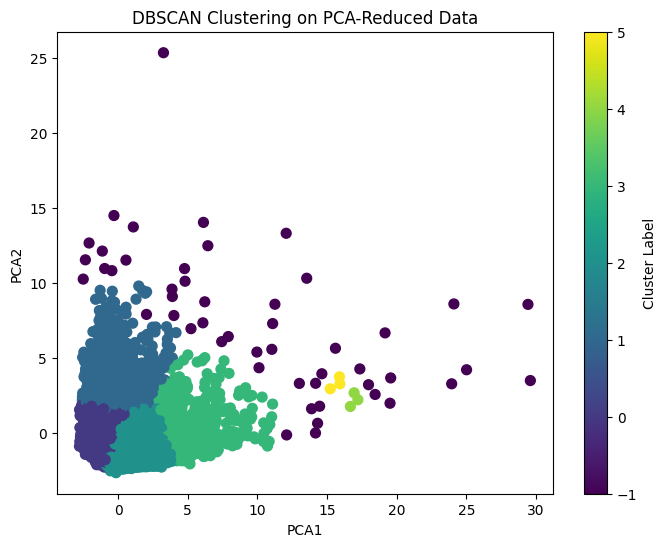

In [20]:
dbscan = DBSCAN(eps=0.9, min_samples=3)
dbscan_labels = dbscan.fit_predict(pca_df)

pca_df['Cluster'] = dbscan_labels


print(pca_df.head())

plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PCA1"], pca_df["PCA2"], c=pca_df["Cluster"], cmap="viridis", s=50)
plt.title("DBSCAN Clustering on PCA-Reduced Data")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Cluster Label")
plt.show()

### <a id="74">Meanshift</a>

       PCA1      PCA2  Cluster
0 -1.683649 -1.072244        0
1 -1.134076  2.509154        0
2  0.969381 -0.383588        0
3 -0.888223  0.004643        0
4 -1.600020 -0.683797        0


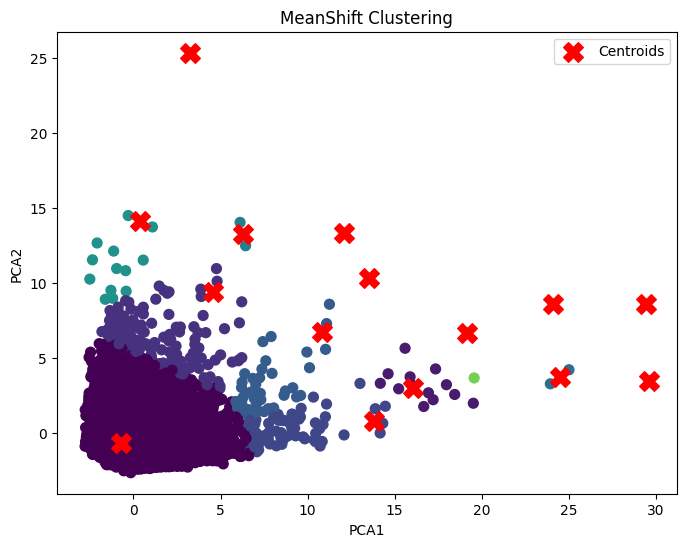

In [21]:
# Khởi tạo MeanShift
meanshift = MeanShift()
meanshift_labels = meanshift.fit_predict(pca_df[["PCA1", "PCA2"]])

# Thêm nhãn cụm vào DataFrame
pca_df['Cluster'] = meanshift_labels

# Hiển thị kết quả
print(pca_df.head())

# Trực quan hóa kết quả
plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PCA1"], pca_df["PCA2"], c=pca_df["Cluster"], cmap="viridis", s=50)
plt.scatter(meanshift.cluster_centers_[:, 0], meanshift.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("MeanShift Clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.show()

### <a id="75">Ward</a>

       PCA1      PCA2  Cluster
0 -1.683649 -1.072244        1
1 -1.134076  2.509154        1
2  0.969381 -0.383588        2
3 -0.888223  0.004643        1
4 -1.600020 -0.683797        1


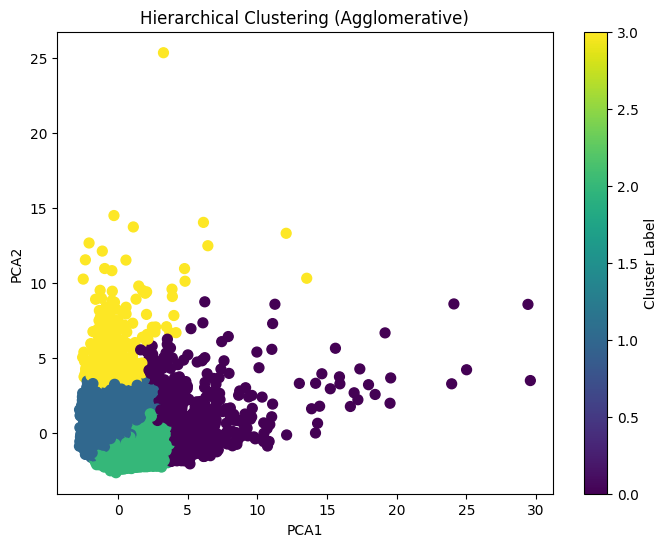

In [22]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')  
hierarchical_labels = hierarchical.fit_predict(pca_df[["PCA1", "PCA2"]])


pca_df['Cluster'] = hierarchical_labels


print(pca_df.head())


plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PCA1"], pca_df["PCA2"], c=pca_df["Cluster"], cmap="viridis", s=50)
plt.title("Hierarchical Clustering (Agglomerative)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Cluster Label")
plt.show()

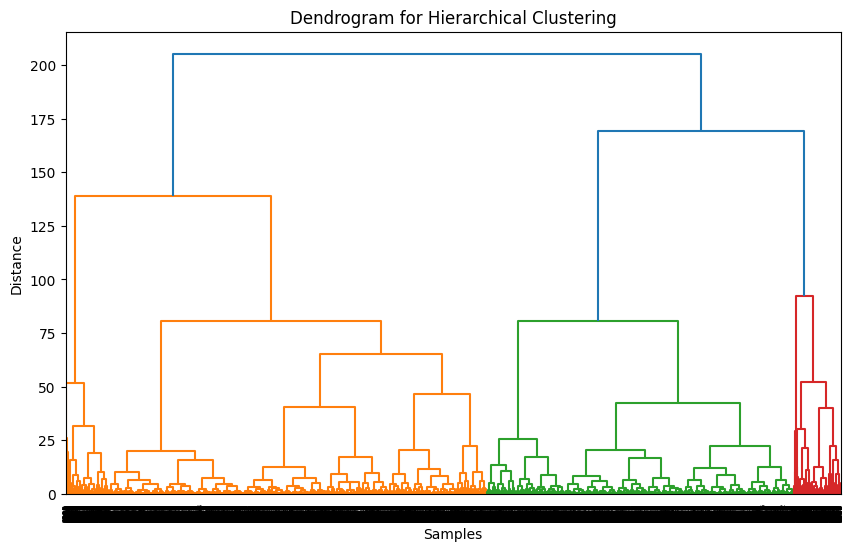

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Tính toán ma trận liên kết
Z = linkage(pca_df[["PCA1", "PCA2"]], method='ward')  # 'ward', 'single', 'complete', 'average' là các lựa chọn

# Vẽ Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# <a id="8">Conclusion</a>

To determine which of the four models (DBSCAN, Hierarchical Clustering, K-Means, MeanShift) performs best, we need to evaluate them based on specific metrics. 

Silhouette Score
Measures how similar a point is to its own cluster (cohesion) compared to other clusters (separation).
Formula:
Silhouette Score

Silhouette Score= b−a/ max(a,b)

​where:
* a: Average distance between a point and other points in the same cluster.
* b: Average distance between a point and the nearest cluster.
Values range from -1 (poor clustering) to 1 (excellent clustering).

In [24]:
from sklearn.metrics import silhouette_score

# Tính Silhouette Score cho từng model
silhouette_dbscan = silhouette_score(pca_df[["PCA1", "PCA2"]], dbscan_labels)
silhouette_hierarchical = silhouette_score(pca_df[["PCA1", "PCA2"]], hierarchical_labels)
silhouette_kmeans = silhouette_score(pca_df[["PCA1", "PCA2"]], kmeans_labels)
silhouette_meanshift = silhouette_score(pca_df[["PCA1", "PCA2"]], meanshift_labels)

print(f"Silhouette Score - DBSCAN: {silhouette_dbscan}")
print(f"Silhouette Score - Hierarchical: {silhouette_hierarchical}")
print(f"Silhouette Score - K-Means: {silhouette_kmeans}")
print(f"Silhouette Score - MeanShift: {silhouette_meanshift}")


Silhouette Score - DBSCAN: 0.40619780508291087
Silhouette Score - Hierarchical: 0.3726267318114776
Silhouette Score - K-Means: 0.4073598449509913
Silhouette Score - MeanShift: 0.5552599452195462


Davies-Bouldin Index

Measures the ratio of within-cluster scatter to between-cluster separation.
Lower values indicate better clustering.

In [25]:
from sklearn.metrics import davies_bouldin_score

# Tính Davies-Bouldin Index cho từng model
db_index_dbscan = davies_bouldin_score(pca_df[["PCA1", "PCA2"]], dbscan_labels)
db_index_hierarchical = davies_bouldin_score(pca_df[["PCA1", "PCA2"]], hierarchical_labels)
db_index_kmeans = davies_bouldin_score(pca_df[["PCA1", "PCA2"]], kmeans_labels)
db_index_meanshift = davies_bouldin_score(pca_df[["PCA1", "PCA2"]], meanshift_labels)

print(f"Davies-Bouldin Index - DBSCAN: {db_index_dbscan}")
print(f"Davies-Bouldin Index - Hierarchical: {db_index_hierarchical}")
print(f"Davies-Bouldin Index - K-Means: {db_index_kmeans}")
print(f"Davies-Bouldin Index - MeanShift: {db_index_meanshift}")


Davies-Bouldin Index - DBSCAN: 1.0541029346366388
Davies-Bouldin Index - Hierarchical: 0.8396136109339554
Davies-Bouldin Index - K-Means: 0.8009924477009159
Davies-Bouldin Index - MeanShift: 0.5463515512140328


Calinski-Harabasz Index

Measures the ratio of between-cluster dispersion to within-cluster dispersion.
Higher values indicate better clustering.

In [26]:
from sklearn.metrics import calinski_harabasz_score

# Tính Calinski-Harabasz Index cho từng model
ch_index_dbscan = calinski_harabasz_score(pca_df[["PCA1", "PCA2"]], dbscan_labels)
ch_index_hierarchical = calinski_harabasz_score(pca_df[["PCA1", "PCA2"]], hierarchical_labels)
ch_index_kmeans = calinski_harabasz_score(pca_df[["PCA1", "PCA2"]], kmeans_labels)
ch_index_meanshift = calinski_harabasz_score(pca_df[["PCA1", "PCA2"]], meanshift_labels)

print(f"Calinski-Harabasz Index - DBSCAN: {ch_index_dbscan}")
print(f"Calinski-Harabasz Index - Hierarchical: {ch_index_hierarchical}")
print(f"Calinski-Harabasz Index - K-Means: {ch_index_kmeans}")
print(f"Calinski-Harabasz Index - MeanShift: {ch_index_meanshift}")


Calinski-Harabasz Index - DBSCAN: 3530.0885528947324
Calinski-Harabasz Index - Hierarchical: 4902.833130455747
Calinski-Harabasz Index - K-Means: 5819.171860444463
Calinski-Harabasz Index - MeanShift: 370.75610654860014


After computing the metrics, compare their values:

* Silhouette Score: Higher values are better.
* Davies-Bouldin Index: Lower values are better.
* Calinski-Harabasz Index: Higher values are better

<div style="font-size:20px;border: 1px solid black; padding: 5px; border-radius: 3px; width: fit-content;">
    
**Final model**:   KMEANS


In [27]:
cluster_df = pd.concat([data,pd.DataFrame({'Cluster':kmeans.labels_})],axis=1)
cluster_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,0
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6,0
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,2
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,2


In [28]:
cluster_1_df = cluster_df[cluster_df["Cluster"]==0]
cluster_1_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
2,2495.148862,1.0,773.17,773.17,0.00,0.0,1.000000,1.00,0.000000,0.0,0,12,7500.0,622.066742,627.284787,0.00,12,0
5,1809.828751,1.0,1333.28,0.00,1333.28,0.0,0.666667,0.00,0.583333,0.0,0,8,1800.0,1400.057770,2407.246035,0.00,12,0
7,1823.652743,1.0,436.20,0.00,436.20,0.0,1.000000,0.00,1.000000,0.0,0,12,2300.0,679.065082,532.033990,0.00,12,0
10,1293.124939,1.0,920.12,0.00,920.12,0.0,1.000000,0.00,1.000000,0.0,0,12,1200.0,1083.301007,2172.697765,0.00,12,0
12,1516.928620,1.0,3217.99,2500.23,717.76,0.0,1.000000,0.25,0.916667,0.0,0,26,3000.0,608.263689,490.207013,0.25,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8936,108.977282,1.0,712.50,0.00,712.50,0.0,1.000000,0.00,0.833333,0.0,0,6,1000.0,605.716356,86.868595,0.75,6,0
8940,130.838554,1.0,591.24,0.00,591.24,0.0,1.000000,0.00,0.833333,0.0,0,6,1000.0,475.523262,82.771320,1.00,6,0
8942,40.829749,1.0,113.28,0.00,113.28,0.0,1.000000,0.00,0.833333,0.0,0,6,1000.0,94.488828,86.283101,0.25,6,0
8945,28.493517,1.0,291.12,0.00,291.12,0.0,1.000000,0.00,0.833333,0.0,0,6,1000.0,325.594462,48.886365,0.50,6,0


In [29]:
cluster_2_df = cluster_df[cluster_df["Cluster"]==1]
cluster_2_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,1
15,6886.213231,1.000000,1611.70,0.00,1611.70,2301.491267,0.500000,0.000000,0.500000,0.166667,4,11,8000.0,1993.439277,2109.906490,0.000000,12,1
23,3800.151377,0.818182,4248.35,3454.56,793.79,7974.415626,1.000000,0.083333,0.916667,0.333333,13,13,9000.0,9479.043842,1425.426525,0.000000,12,1
24,5368.571219,1.000000,0.00,0.00,0.00,798.949863,0.000000,0.000000,0.000000,0.363636,4,0,6000.0,1422.726707,1657.002877,0.000000,11,1
28,7152.864372,1.000000,387.05,204.55,182.50,2236.145259,0.666667,0.166667,0.416667,0.833333,16,8,10500.0,1601.448347,1648.851345,0.000000,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835,1868.576501,1.000000,1337.34,1294.84,42.50,3132.667468,0.833333,0.833333,0.166667,1.000000,10,23,3000.0,3236.129237,384.230828,0.000000,6,1
8840,2588.410789,0.888889,787.40,0.00,787.40,3762.650329,0.777778,0.000000,0.666667,0.555556,10,17,3000.0,1739.406636,1769.001229,0.000000,9,1
8857,2330.222764,1.000000,1320.00,0.00,1320.00,14926.790590,0.428571,0.000000,0.285714,0.571429,10,3,10000.0,8157.666434,283.362434,0.200000,7,1
8858,812.934042,1.000000,50.00,50.00,0.00,2185.500596,0.142857,0.142857,0.000000,1.000000,16,1,3000.0,726.683966,127.843735,0.000000,7,1


In [30]:
cluster_3_df = cluster_df[cluster_df["Cluster"]==2]
cluster_3_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.00,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.00,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.00,12,2
8,1014.926473,1.000000,861.49,661.49,200.0,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.00,12,2
9,152.225975,0.545455,1281.60,1281.60,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.00,12,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8943,5.871712,0.500000,20.90,20.90,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0,1,500.0,58.644883,43.473717,0.00,6,2
8944,193.571722,0.833333,1012.73,1012.73,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,4000.0,0.000000,312.343947,0.00,6,2
8947,23.398673,0.833333,144.40,0.00,144.4,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6,2
8948,13.457564,0.833333,0.00,0.00,0.0,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6,2


In [31]:
cluster_4_df = cluster_df[cluster_df["Cluster"] == 3]
cluster_4_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12,3
21,6369.531318,1.000000,6359.95,5910.04,449.91,229.028245,1.000000,0.916667,1.000000,0.333333,6,92,11250.0,2077.959051,1659.775075,0.000000,12,3
30,12136.219960,1.000000,3038.01,1013.20,2024.81,3183.583301,1.000000,0.166667,1.000000,0.500000,10,64,13000.0,4230.323491,3292.015030,0.000000,12,3
57,2386.330629,1.000000,5217.62,4789.09,428.53,0.000000,0.916667,0.916667,0.500000,0.000000,0,42,7500.0,5678.729613,1311.514878,0.083333,12,3
84,1935.362486,1.000000,4915.60,4515.34,400.26,293.844792,1.000000,1.000000,0.333333,0.083333,1,50,9000.0,4921.066897,594.756686,0.000000,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8215,4436.557694,1.000000,6005.90,5838.38,167.52,567.971877,1.000000,0.583333,0.916667,0.083333,1,61,10500.0,1650.425296,1067.515656,0.000000,12,3
8541,3326.323283,1.000000,8209.77,2218.28,5991.49,0.000000,1.000000,0.416667,1.000000,0.000000,0,130,10000.0,1942.074765,702.905059,0.083333,12,3
8662,599.909949,1.000000,4947.32,3149.59,1797.73,0.000000,1.000000,1.000000,0.916667,0.000000,0,73,3000.0,5024.430008,218.172915,0.083333,12,3
8689,368.318662,0.909091,8053.95,8053.95,0.00,0.000000,0.833333,0.833333,0.000000,0.000000,0,46,2000.0,7966.582037,219.761189,0.777778,12,3


**Visualization**

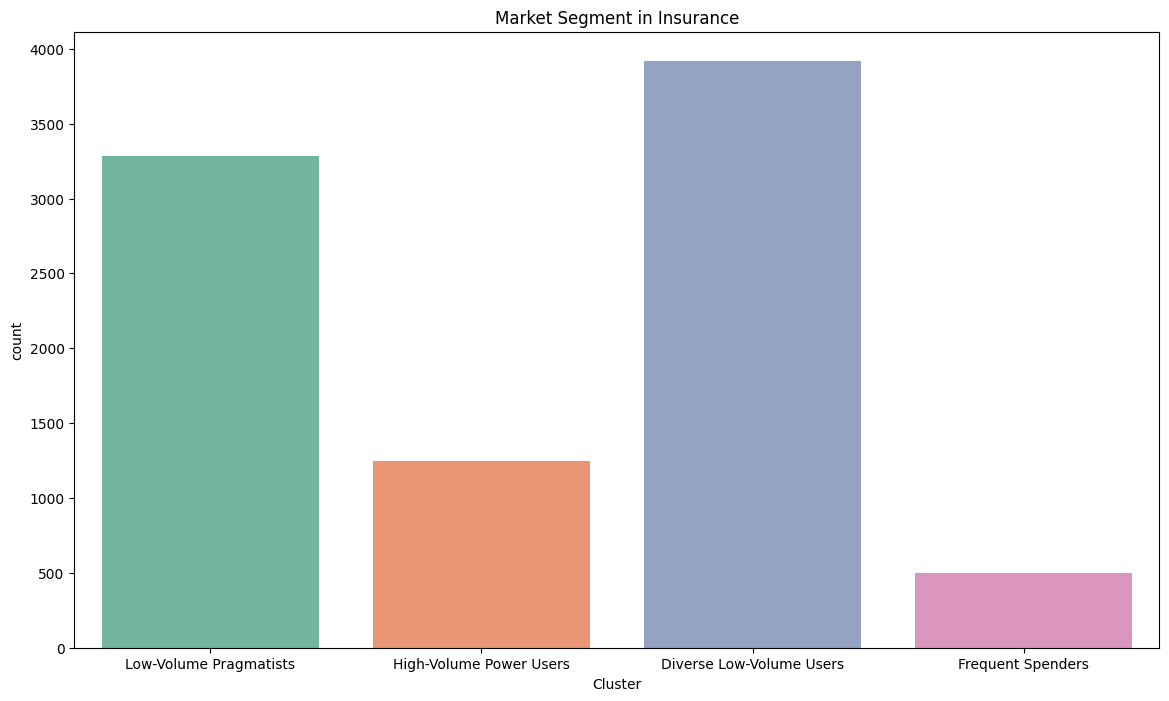

In [32]:
# Plotting the countplot
plt.figure(figsize=(14, 8))
sns.countplot(x='Cluster', data=cluster_df, palette='Set2')
plt.title("Market Segment in Insurance")
# Renaming x-axis labels to your custom cluster names
plt.xticks(ticks=[0, 1, 2, 3], labels=["Low-Volume Pragmatists", "High-Volume Power Users", 
                                         "Diverse Low-Volume Users", "Frequent Spenders"])

# Display the plot
plt.savefig('barchart123.pdf')
plt.show()

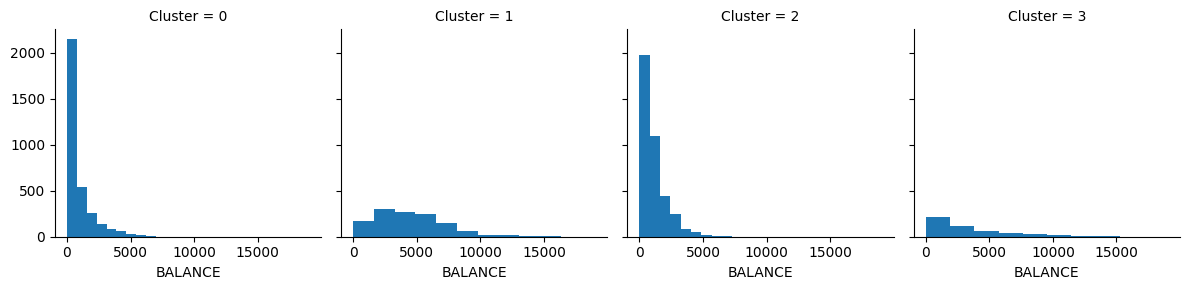

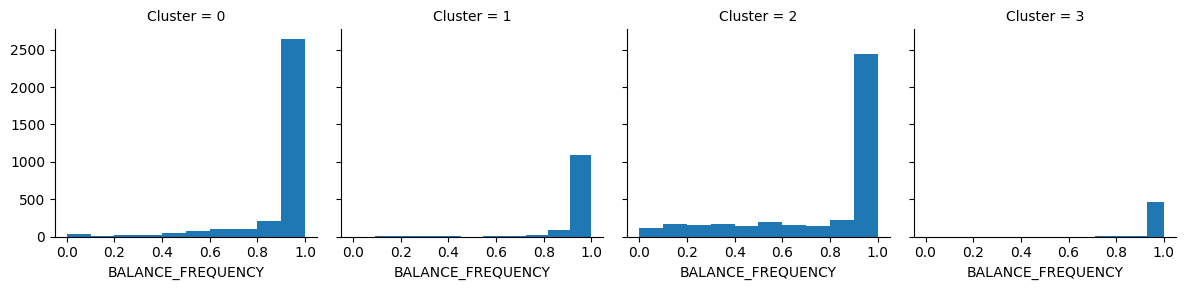

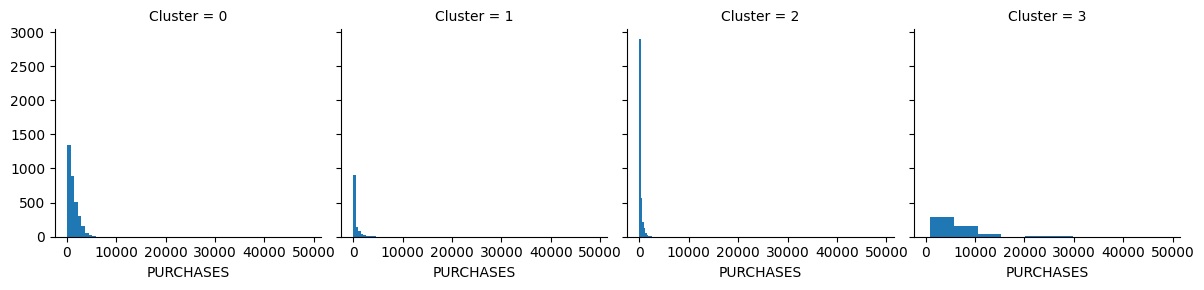

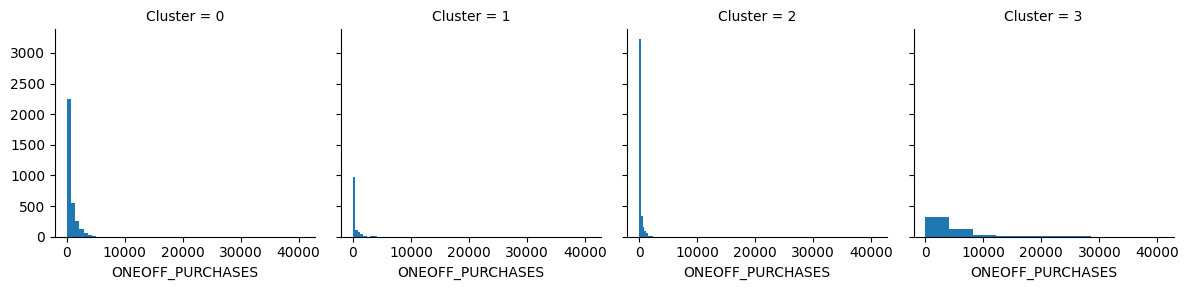

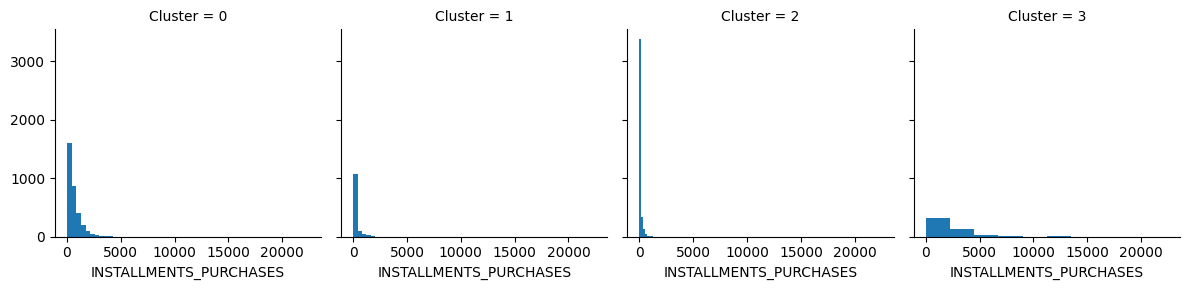

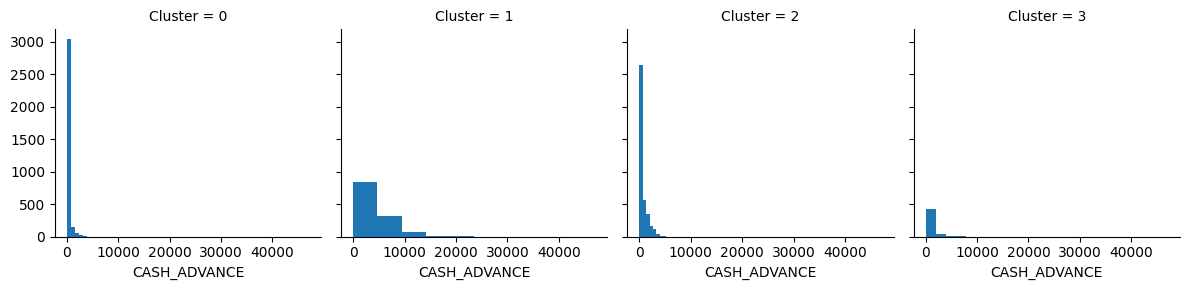

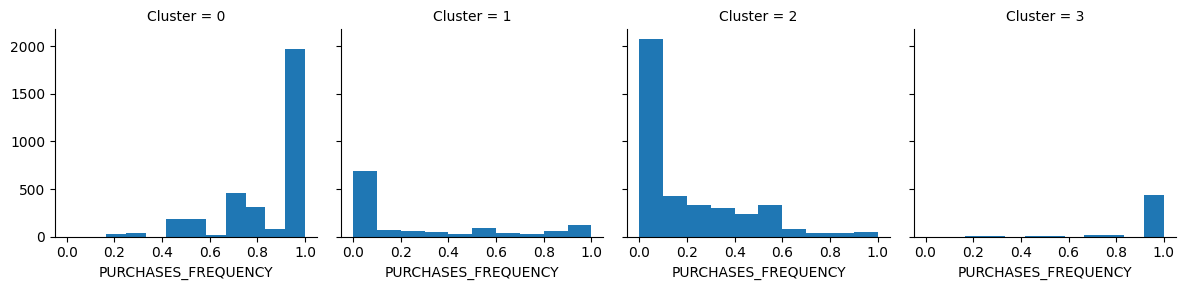

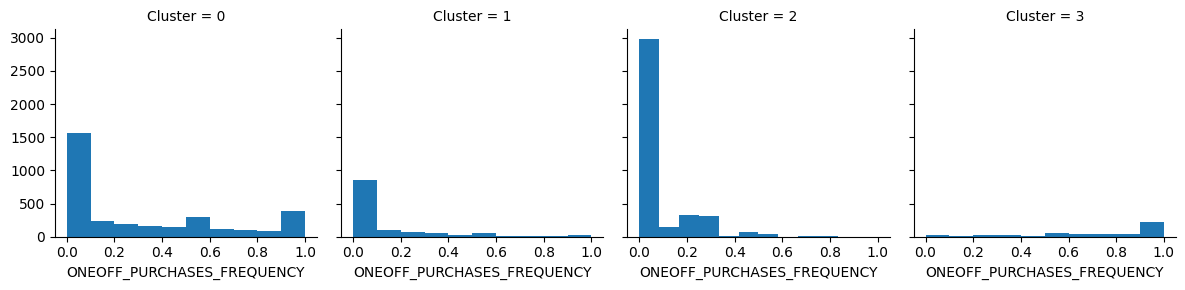

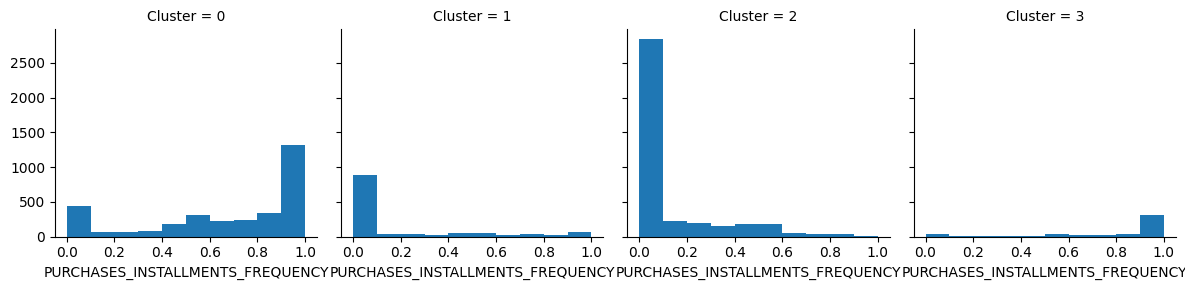

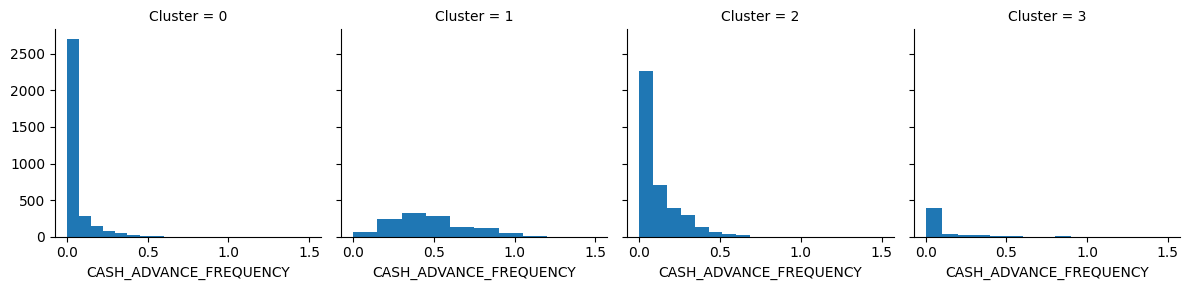

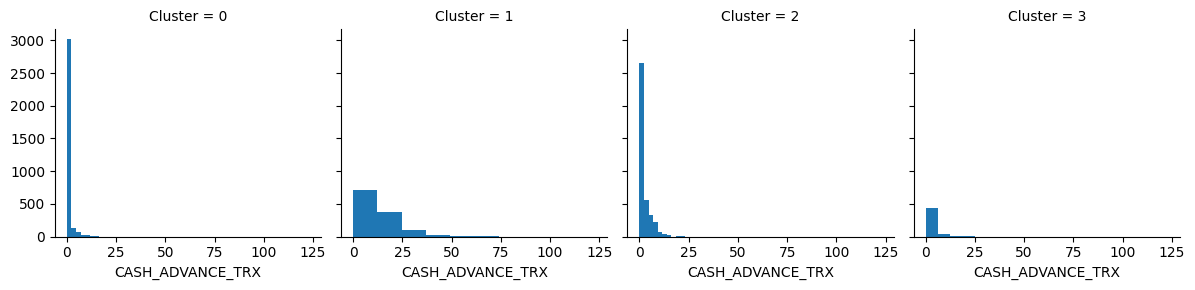

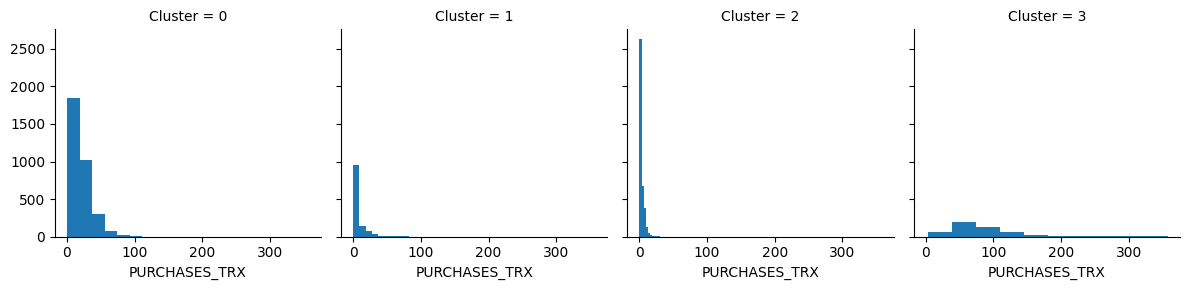

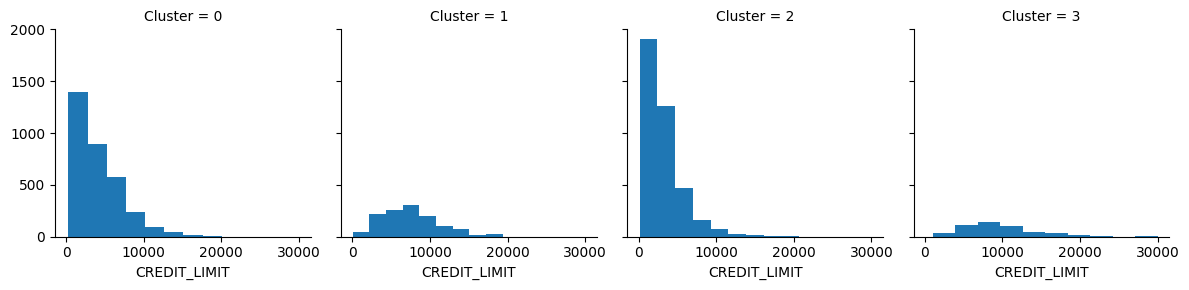

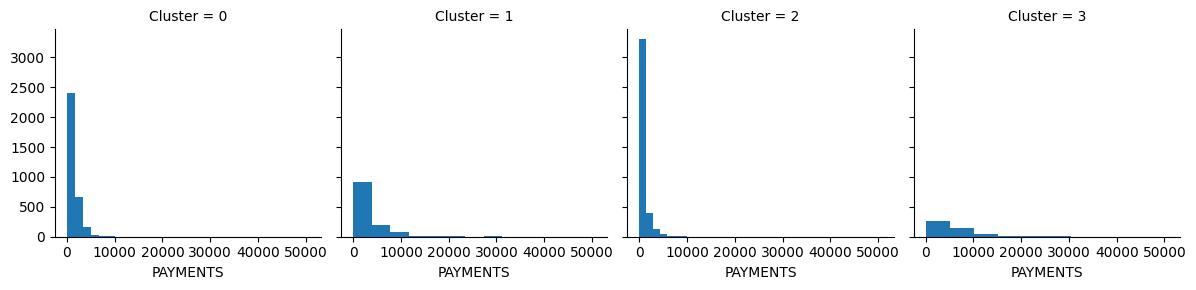

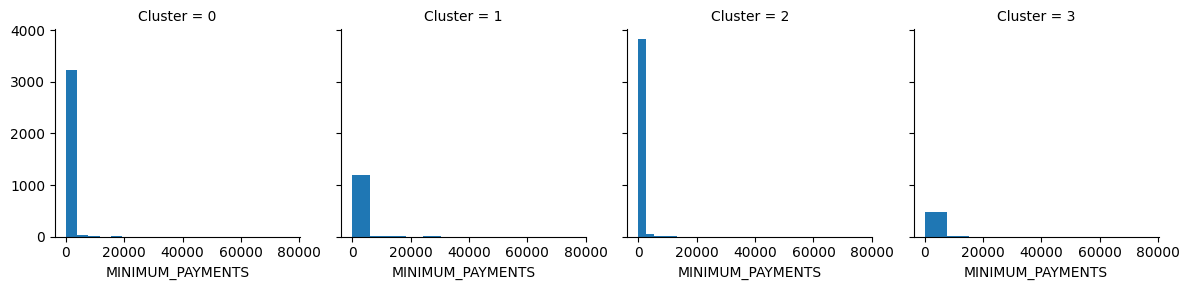

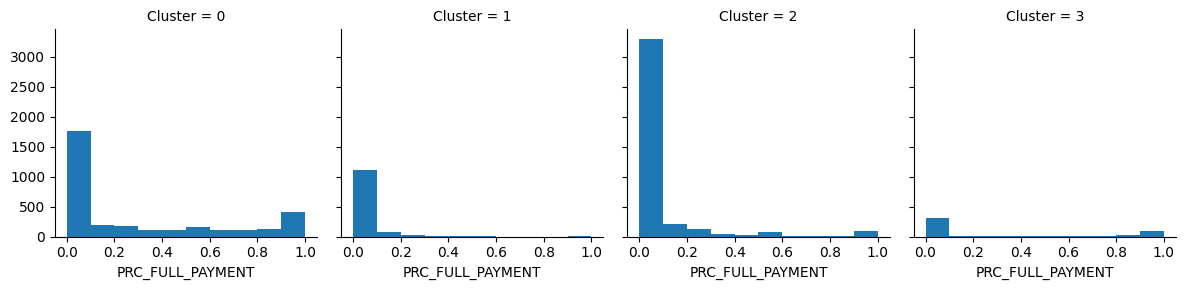

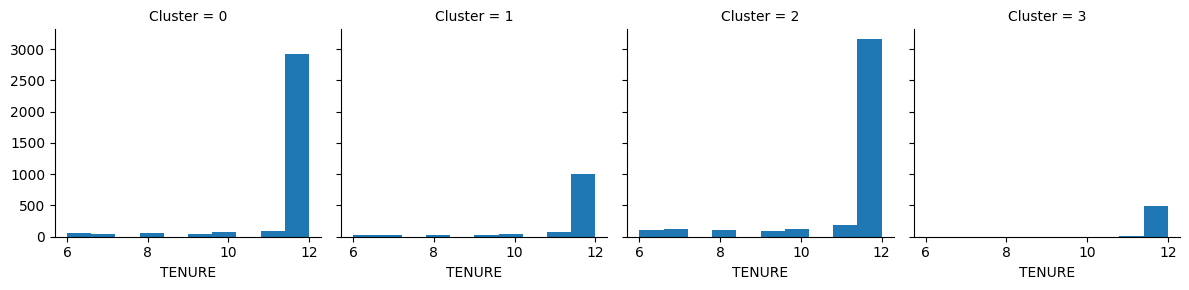

In [33]:
for c in cluster_df.drop(['Cluster'],axis=1):
    grid= sns.FacetGrid(cluster_df, col='Cluster')
    grid= grid.map(plt.hist, c)
plt.show()

### <a id="21">Key Clusters</a>
<div style="border: 2px solid purple; padding: 5px; border-radius: 3px; width: fit-content;">
    
Cluster 1: **"Low-Volume Pragmatists"**
* Characterized by low financial activity and low credit utilization.
* Tend to maintain low balances and engage in minimal transactions, focusing on stability rather than volume.

Cluster 2: **"High-Volume Power Users"**
* Exhibit high transaction volumes and significant variability in credit limits.
* These are likely the heavy users of financial services, actively engaging with their accounts.

Cluster 3: **"Diverse Low-Volume Users"**
* Similar to Cluster 1 but with greater variability in their financial behavior.
* May indicate a mix of sporadic or inconsistent usage patterns.

Cluster 4: **"Frequent Spenders"**
* Resemble Cluster 2 but with a distinct focus on frequent purchases, particularly installment-based transactions.
* High variability in payment behaviors suggests a mix of disciplined and opportunistic spending habits.

</div>

### Thank you for completing this lab!


## Author

<a href="https://www.linkedin.com/in/vinhdac/" target="_blank">Nguyen Dac Vinh</a>


## <h3 align="center"> © Personal Project 2024. All rights reserved. <h3/>


